# レンディング

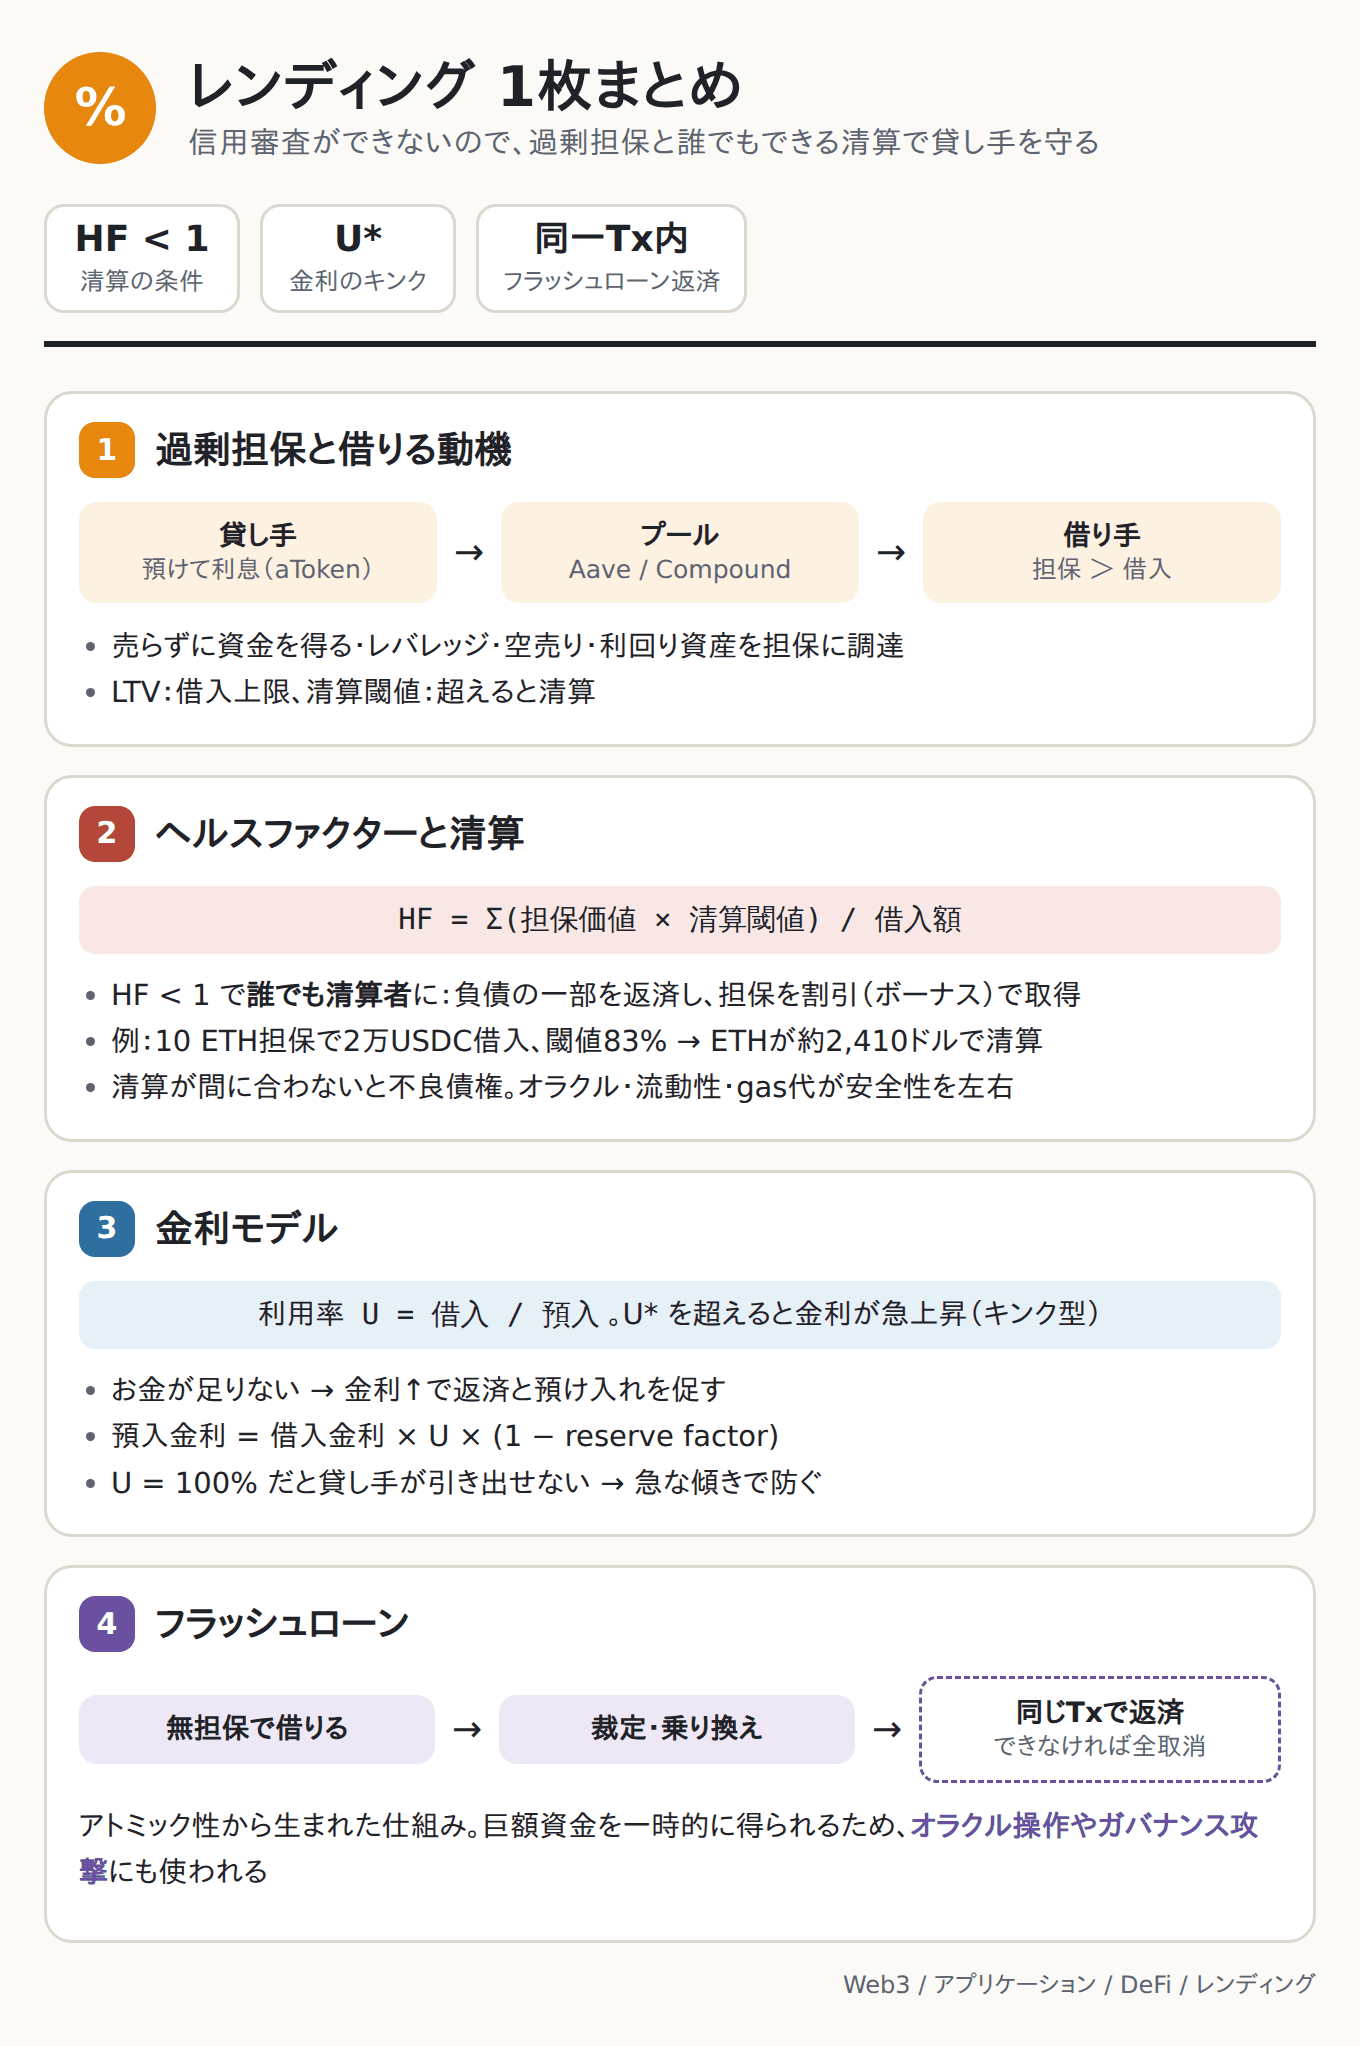

## 分散型レンディングとは

**レンディングプロトコル** は、暗号資産の貸し手と借り手をスマートコントラクトの資金プールでつなぐ仕組み。代表例はAave、Compound、Morpho。

- **貸し手（供給者）**：資産をプールに預け、利息を受け取る
- **借り手**：担保を預けて、別の資産をプールから借りる

従来の金融と大きく違うのは、**相手の信用を審査できない** こと。借り手は匿名のアドレスにすぎず、返済しなくても追いかける手段がない。そこで、借りる額より多くの担保を預けさせる **過剰担保（over-collateralization）** を前提にしている。

借りた額より多い担保を預けるなら、担保を売ればよいのでは？と思うかもしれないが、借りる動機には次のようなものがある。

- 保有資産を売らずに資金を得たい（売却益への課税を避ける、値上がりを期待して持ち続けたい）
- レバレッジをかけたい（ETHを担保にUSDCを借りてETHを買い増す）
- 空売りしたい（価格が下がると思うトークンを借りて売る）
- 利回りのつく資産（stETHなど）を担保にして、利回りを得ながら資金を調達したい

## 担保と清算

### パラメーター

| 用語 | 意味 |
| --- | --- |
| LTV（Loan to Value） | 担保の価値に対して借りられる上限の割合（例：80%） |
| 清算閾値（liquidation threshold） | 担保価値に対する借入額がこれを超えると清算される（例：83%） |
| 清算ボーナス（liquidation bonus） | 清算者が得る割引（例：5%） |
| ヘルスファクター | ポジションの健全性の指標 |

Aaveではヘルスファクターを

$$
HF = \frac{\sum_i (\text{担保}_i \text{の価値} \times \text{清算閾値}_i)}{\text{借入額の価値}}
$$

と定義し、$HF < 1$ になると清算の対象になる。

### 清算

担保の価格が下がって $HF < 1$ になると、**誰でも清算者（liquidator）** になれる。清算者は借り手の負債の一部（例えば50%）を代わりに返済し、その分の担保を清算ボーナス付きの割引価格で受け取る。

- 清算者にとっては割安に担保を買える裁定機会なので、ボットが常に監視している（Keeper）
- 借り手にとっては、清算ボーナス分のペナルティを負うことになる
- 担保価値が負債を下回る前に清算されることで、貸し手の資金が守られる

担保の価格が急落し、清算が間に合わずに担保価値が負債を下回ると、プロトコルに **不良債権（bad debt）** が残る。そのため、清算の効率（オラクルの更新頻度、DEXの流動性、ガス代の高騰）はプロトコルの安全性に直結する。

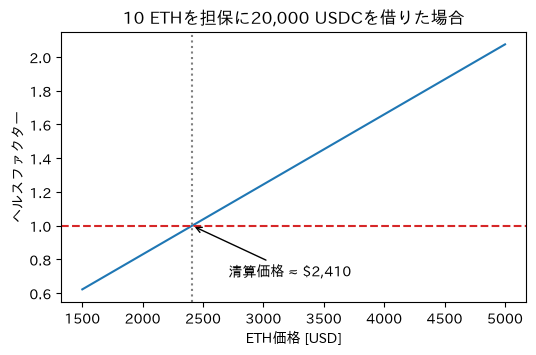

In [1]:
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401
import numpy as np

collateral_eth = 10.0
debt_usdc = 20_000
threshold = 0.83

prices = np.linspace(1500, 5000, 300)
hf = collateral_eth * prices * threshold / debt_usdc
liq_price = debt_usdc / (collateral_eth * threshold)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(prices, hf)
ax.axhline(1, color="C3", ls="--")
ax.axvline(liq_price, color="gray", ls=":")
ax.annotate(f"清算価格 ≈ ${liq_price:,.0f}", (liq_price, 1), xytext=(liq_price + 300, 0.7), arrowprops=dict(arrowstyle="->"))
ax.set(xlabel="ETH価格 [USD]", ylabel="ヘルスファクター", title="10 ETHを担保に20,000 USDCを借りた場合")
plt.show()

## 金利モデル

貸し手が受け取る利息と借り手が支払う利息は、プールの **利用率（utilization rate）** で自動的に決まる。

$$
U = \frac{\text{借りられている額}}{\text{預けられている額}}
$$

- 利用率が高い（お金が足りない）→ 金利を上げて、借り手に返済を、貸し手に預け入れを促す
- 利用率が低い（お金が余っている）→ 金利を下げて、借り入れを促す

利用率が100%になると、貸し手が資金を引き出せなくなる。そこで多くのプロトコルは、最適な利用率 $U^*$（例：80〜90%）を境に傾きが急になる **キンク型（kinked）** の金利モデルを採用している。

$$
r_{\text{borrow}}(U) = \begin{cases} r_0 + \dfrac{U}{U^*} s_1 & (U \le U^*) \\[2mm] r_0 + s_1 + \dfrac{U - U^*}{1 - U^*} s_2 & (U > U^*) \end{cases}
$$

貸し手の金利は、借り手の支払う利息を預け入れ額全体で分け合うので、

$$
r_{\text{supply}} = r_{\text{borrow}} \cdot U \cdot (1 - \text{reserve factor})
$$

となる（reserve factorはプロトコルの取り分）。

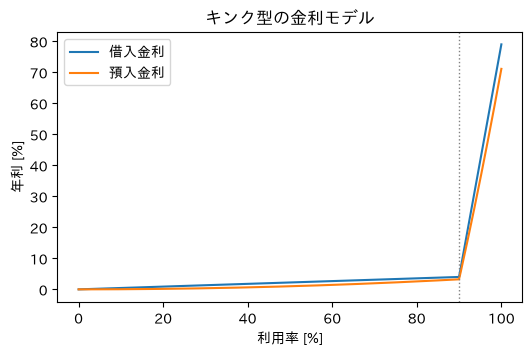

In [2]:
def borrow_rate(u, base=0.0, slope1=0.04, slope2=0.75, u_opt=0.9):
    return np.where(u <= u_opt, base + u / u_opt * slope1, base + slope1 + (u - u_opt) / (1 - u_opt) * slope2)


u = np.linspace(0, 1, 500)
rb = borrow_rate(u)
rs = rb * u * (1 - 0.1)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(u * 100, rb * 100, label="借入金利")
ax.plot(u * 100, rs * 100, label="預入金利")
ax.axvline(90, color="gray", ls=":", lw=1)
ax.set(xlabel="利用率 [%]", ylabel="年利 [%]", title="キンク型の金利モデル")
ax.legend()
plt.show()

預け入れると、預けた量を表す利付きトークン（AaveのaToken、CompoundのcToken）を受け取る。aTokenは残高そのものが利息に応じて増えていき、cTokenは枚数は変わらず交換レートが上がっていく。これらのトークンは、他のDeFiプロトコルでさらに運用できる。

## フラッシュローン

**フラッシュローン（flash loan）** は、**同じトランザクション内で返済することを条件に、無担保で** いくらでも借りられる仕組み。トランザクションの最後に返済されていなければ、トランザクション全体が取り消される（revert）ので、貸し手はリスクを負わない。

```mermaid
sequenceDiagram
    participant U as ユーザーのコントラクト
    participant L as レンディングプール
    participant A as DEX A
    participant B as DEX B
    L->>U: 1,000,000 USDCを貸す
    U->>A: USDCでETHを買う（安い）
    U->>B: ETHをUSDCで売る（高い）
    U->>L: 1,000,000 USDC + 手数料を返済
    Note over U,L: 返済できなければトランザクション全体が取り消される
```

これは、トランザクションのアトミック性というブロックチェーン特有の性質から生まれた、従来の金融には存在しない仕組み。

用途：

- 裁定取引（資金なしで価格差を取る）
- 担保の乗り換え、自己清算
- 負債の借り換え

一方で、**攻撃者が巨額の資金を一時的に手にできる** ため、オラクルの価格操作やガバナンス攻撃の道具としても使われてきた（→[オラクル](./oracles.ipynb)、[DAO](../dao.ipynb)）。

## プロトコルの例

| プロトコル | 特徴 |
| --- | --- |
| Compound | 2018年。プール型レンディングの先駆け。COMPトークンの配布で「流動性マイニング」ブームを起こした（2020年） |
| Aave | 最大規模のレンディングプロトコル。フラッシュローンを普及させた。多くのチェーンに展開 |
| Morpho | 貸し手と借り手を個別のマーケット（担保と借入資産の組み合わせ）ごとに分離し、リスクを隔離する。キュレーターがボールトの運用先を選ぶ |
| MakerDAO（Sky） | 担保を預けて自らステーブルコイン（DAI/USDS）を発行する（→[ステーブルコイン](./stablecoins.ipynb)） |

## 参考文献

- [Aave Documentation](https://aave.com/docs)
- Leshner, R. & Hayes, G. (2019). [Compound: The Money Market Protocol](https://web.archive.org/web/20260908070214/https://compound.finance/documents/Compound.Whitepaper.pdf).
- Qin, K. et al. (2021). [Attacking the DeFi Ecosystem with Flash Loans for Fun and Profit](https://arxiv.org/abs/2003.03810). Financial Cryptography.
- Gudgeon, L. et al. (2020). [DeFi Protocols for Loanable Funds: Interest Rates, Liquidity and Market Efficiency](https://arxiv.org/abs/2006.13922). ACM AFT.